Customer Intelligence System


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split

#Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    silhouette_score
)
import warnings
warnings.filterwarnings("ignore")


In [53]:
df=pd.read_csv("marketing_campaign.csv",sep="\t")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [54]:
print("Shape:",df.shape)
df.info()
df.describe()

Shape: (2240, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases   

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [55]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [56]:
df=df.dropna()

In [57]:
#Feature Engineering
df["Total_Spending"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)
df["Total_Purchases"] = (
    df["NumWebPurchases"] +
    df["NumCatalogPurchases"] +
    df["NumStorePurchases"]
)

In [58]:
df=df.drop(["ID","Dt_Customer"],axis=1)

In [59]:
le=LabelEncoder()
df["Education"]=le.fit_transform(df["Education"])
df["Marital_Status"]=le.fit_transform(df["Marital_Status"])

In [60]:
#Target
X=df.drop("Response",axis=1)
y=df["Response"]

In [61]:
#Feature Scaling
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [62]:
#Spliting using train test split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

Classification Models


In [63]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(X_train,y_train)
pred_lr=lr.predict(X_test)
print("Logistic Regression Metrics:")
print("Accuracy Score:",accuracy_score(y_test,pred_lr))
print("Classification Report:",classification_report(y_test,pred_lr))
print("Confusion Matrix:",confusion_matrix(y_test,pred_lr))


Logistic Regression Metrics:
Accuracy Score: 0.8716216216216216
Classification Report:               precision    recall  f1-score   support

           0       0.88      0.98      0.93       382
           1       0.62      0.21      0.31        62

    accuracy                           0.87       444
   macro avg       0.75      0.59      0.62       444
weighted avg       0.85      0.87      0.84       444

Confusion Matrix: [[374   8]
 [ 49  13]]


In [64]:
#Naive Bayes
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()

nb.fit(X_train, y_train)

pred_nb = nb.predict(X_test)

print("Naive Bayes Metrics:")
print("Accuracy Score:",accuracy_score(y_test,pred_nb))
print("Classification Report:",classification_report(y_test,pred_nb))
print("Confusion Matrix:",confusion_matrix(y_test,pred_nb))


Naive Bayes Metrics:
Accuracy Score: 0.7162162162162162
Classification Report:               precision    recall  f1-score   support

           0       0.91      0.75      0.82       382
           1       0.25      0.52      0.34        62

    accuracy                           0.72       444
   macro avg       0.58      0.63      0.58       444
weighted avg       0.81      0.72      0.75       444

Confusion Matrix: [[286  96]
 [ 30  32]]


In [65]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

print("KNN Metrics:")
print("Accuracy Score:",accuracy_score(y_test,pred_knn))
print("Classification Report:",classification_report(y_test,pred_knn))
print("Confusion Matrix:",confusion_matrix(y_test,pred_knn))

KNN Metrics:
Accuracy Score: 0.8693693693693694
Classification Report:               precision    recall  f1-score   support

           0       0.89      0.97      0.93       382
           1       0.57      0.27      0.37        62

    accuracy                           0.87       444
   macro avg       0.73      0.62      0.65       444
weighted avg       0.85      0.87      0.85       444

Confusion Matrix: [[369  13]
 [ 45  17]]


In [66]:
#SVM
from sklearn.svm import SVC
svm = SVC()

svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

print("SVM Metrics:")
print("Accuracy Score:",accuracy_score(y_test,pred_svm))
print("Classification Report:",classification_report(y_test,pred_svm))
print("Confusion Matrix:",confusion_matrix(y_test,pred_svm))

SVM Metrics:
Accuracy Score: 0.8603603603603603
Classification Report:               precision    recall  f1-score   support

           0       0.86      1.00      0.92       382
           1       0.00      0.00      0.00        62

    accuracy                           0.86       444
   macro avg       0.43      0.50      0.46       444
weighted avg       0.74      0.86      0.80       444

Confusion Matrix: [[382   0]
 [ 62   0]]


In [67]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Decision Tree Metrics:")
print("Accuracy Score:",accuracy_score(y_test,pred_dt))
print("Classification Report:",classification_report(y_test,pred_dt))
print("Confusion Matrix:",confusion_matrix(y_test,pred_dt))

Decision Tree Metrics:
Accuracy Score: 0.8603603603603603
Classification Report:               precision    recall  f1-score   support

           0       0.91      0.93      0.92       382
           1       0.50      0.45      0.47        62

    accuracy                           0.86       444
   macro avg       0.71      0.69      0.70       444
weighted avg       0.85      0.86      0.86       444

Confusion Matrix: [[354  28]
 [ 34  28]]


Ensemble Models


In [68]:
#Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(X_train,y_train)
pred_rf=rf.predict(X_test)
print("Random Forest Classifier Metrics")
print("Accuracy Score:",accuracy_score(y_test,pred_rf))
print("Classification Report:",classification_report(y_test,pred_rf))
print("Confusion Matrix:",confusion_matrix(y_test,pred_rf))


Random Forest Classifier Metrics
Accuracy Score: 0.8851351351351351
Classification Report:               precision    recall  f1-score   support

           0       0.90      0.97      0.94       382
           1       0.66      0.37      0.47        62

    accuracy                           0.89       444
   macro avg       0.78      0.67      0.70       444
weighted avg       0.87      0.89      0.87       444

Confusion Matrix: [[370  12]
 [ 39  23]]


In [69]:
#AdaBoost Classifier
from sklearn.ensemble import AdaBoostClassifier
ada=AdaBoostClassifier()
ada.fit(X_train,y_train)
pred_ada=ada.predict(X_test)
print("AdaBoost Classifier Metrics:")
print("Accuracy Score:",accuracy_score(y_test,pred_ada))
print("Classification Report:",classification_report(y_test,pred_ada))
print("Confusion Matrix:",confusion_matrix(y_test,pred_ada))

AdaBoost Classifier Metrics:
Accuracy Score: 0.8761261261261262
Classification Report:               precision    recall  f1-score   support

           0       0.91      0.95      0.93       382
           1       0.58      0.42      0.49        62

    accuracy                           0.88       444
   macro avg       0.74      0.68      0.71       444
weighted avg       0.86      0.88      0.87       444

Confusion Matrix: [[363  19]
 [ 36  26]]


In [70]:
#Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier
gb=GradientBoostingClassifier()
gb.fit(X_train,y_train)
pred_gb=gb.predict(X_test)
print("Gradient Boosting Classifier Metrics:")
print("Accuracy Score:",accuracy_score(y_test,pred_gb))
print("Classification Report:",classification_report(y_test,pred_gb))
print("Confusion Matrix:",confusion_matrix(y_test,pred_gb))

Gradient Boosting Classifier Metrics:
Accuracy Score: 0.8828828828828829
Classification Report:               precision    recall  f1-score   support

           0       0.91      0.96      0.93       382
           1       0.62      0.40      0.49        62

    accuracy                           0.88       444
   macro avg       0.77      0.68      0.71       444
weighted avg       0.87      0.88      0.87       444

Confusion Matrix: [[367  15]
 [ 37  25]]


In [71]:
#XgBoost
from xgboost import XGBClassifier
xgb=XGBClassifier()
xgb.fit(X_train,y_train)
pred_xgb=xgb.predict(X_test)
print("XGBClassifier Metrics:")
print("Accuracy Score:",accuracy_score(y_test,pred_xgb))
print("Classification Report:",classification_report(y_test,pred_xgb))
print("Confusion Matrix:",confusion_matrix(y_test,pred_xgb))


XGBClassifier Metrics:
Accuracy Score: 0.8851351351351351
Classification Report:               precision    recall  f1-score   support

           0       0.91      0.96      0.94       382
           1       0.63      0.42      0.50        62

    accuracy                           0.89       444
   macro avg       0.77      0.69      0.72       444
weighted avg       0.87      0.89      0.87       444

Confusion Matrix: [[367  15]
 [ 36  26]]


In [72]:
#LightGBM
!pip install lightgbm

In [74]:
#Light BGM
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier()

lgbm.fit(X_train, y_train)

pred_lgbm = lgbm.predict(X_test)

print("LightGBM Metrics:")
print("Accuracy Score:",accuracy_score(y_test,pred_lgbm))
print("Classification Report:",classification_report(y_test,pred_lgbm))
print("Confusion Matrix:",confusion_matrix(y_test,pred_lgbm))


[LightGBM] [Info] Number of positive: 271, number of negative: 1501
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000843 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1816
[LightGBM] [Info] Number of data points in the train set: 1772, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.152935 -> initscore=-1.711768
[LightGBM] [Info] Start training from score -1.711768
LightGBM Metrics:
Accuracy Score: 0.8873873873873874
Classification Report:               precision    recall  f1-score   support

           0       0.92      0.96      0.94       382
           1       0.64      0.45      0.53        62

    accuracy                           0.89       444
   macro avg       0.78      0.70      0.73       444
weighted avg       0.88      0.89      0.88       444

Confusion Matrix: [[366  16]
 [ 34  28]]


In [75]:
#Stacking Classicfication
from sklearn.ensemble import StackingClassifier
estimators=[
    ('rf',RandomForestClassifier()),
    ('xgb',XGBClassifier()),
]
stack=StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)
stack.fit(X_train,y_train)
pred_stack=stack.predict(X_test)
print("Stacking Metrics:")
print("Accuracy Score:",accuracy_score(y_test,pred_stack))
print("Classification Report:",classification_report(y_test,pred_stack))
print("Confusion Matrix:",confusion_matrix(y_test,pred_stack))


Stacking Metrics:
Accuracy Score: 0.8851351351351351
Classification Report:               precision    recall  f1-score   support

           0       0.90      0.97      0.94       382
           1       0.66      0.37      0.47        62

    accuracy                           0.89       444
   macro avg       0.78      0.67      0.70       444
weighted avg       0.87      0.89      0.87       444

Confusion Matrix: [[370  12]
 [ 39  23]]


In [76]:
#Models Comaprision between Classification Models and Ensemble Models
results = {
    "Logistic Regression": accuracy_score(y_test, pred_lr),
    "Naive Bayes": accuracy_score(y_test, pred_nb),
    "KNN": accuracy_score(y_test, pred_knn),
    "SVM": accuracy_score(y_test, pred_svm),
    "Decision Tree": accuracy_score(y_test, pred_dt),
    "Random Forest": accuracy_score(y_test, pred_rf),
    "AdaBoost": accuracy_score(y_test, pred_ada),
    "Gradient Boosting": accuracy_score(y_test, pred_gb),
    "XGBoost": accuracy_score(y_test, pred_xgb),
    "LightGBM": accuracy_score(y_test, pred_lgbm),
    "Stacking": accuracy_score(y_test, pred_stack)
}

comparison = pd.DataFrame(results.items(), columns=["Model", "Accuracy"])

comparison.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
9,LightGBM,0.887387
5,Random Forest,0.885135
8,XGBoost,0.885135
10,Stacking,0.885135
7,Gradient Boosting,0.882883
6,AdaBoost,0.876126
0,Logistic Regression,0.871622
2,KNN,0.869369
3,SVM,0.860360
4,Decision Tree,0.860360


In [77]:
#Feature Importance
importance = rf.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
6,Recency,0.092086
26,Total_Spending,0.070234
3,Income,0.068041
9,MntMeatProducts,0.064845
7,MntWines,0.061495
12,MntGoldProds,0.050106
17,NumWebVisitsMonth,0.047140
0,Year_Birth,0.046182
20,AcceptedCmp5,0.043267
11,MntSweetProducts,0.041605


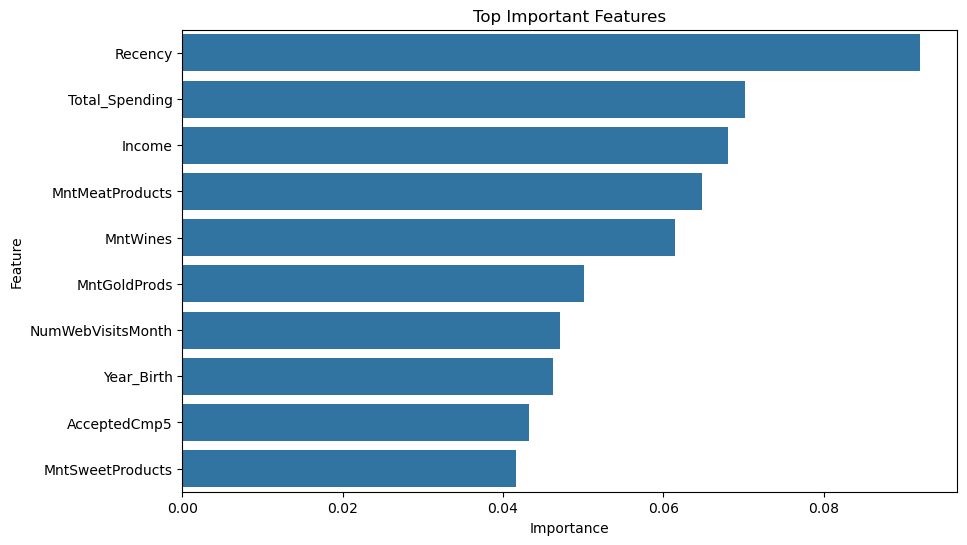

In [78]:
#Visualization
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df.head(10)
)

plt.title("Top Important Features")
plt.show()

Clustering 

In [79]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering


In [80]:
#Elbow Method
wcss=[]
for i in range(1,11):
    km=KMeans(n_clusters=i,random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

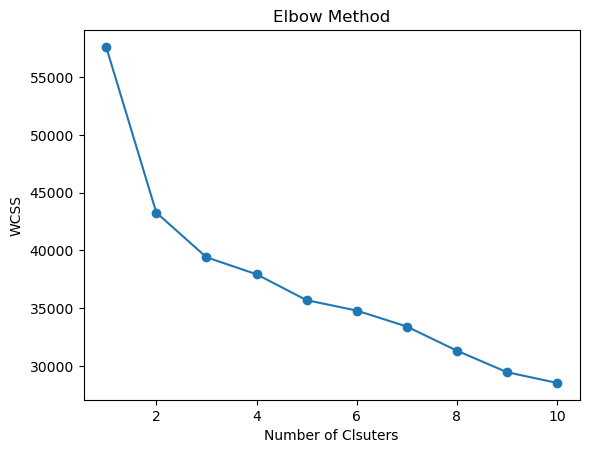

In [81]:
#Plot elbow graph
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("Number of Clsuters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [82]:
#KMeans
kmeans=KMeans(n_clusters=4,random_state=42)
clusters=kmeans.fit_predict(X_scaled)
df["Cluster"]=clusters

In [83]:
#DBSCAN
dbscan=DBSCAN(eps=2,min_samples=5)
db_clusters=dbscan.fit_predict(X_scaled)
df["DBSCAN_Cluster"]=db_clusters

In [84]:
hc=AgglomerativeClustering(n_clusters=4)
hc_clusters=hc.fit_predict(X_scaled)
df["HC_Cluster"]=hc_clusters

In [85]:
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.09807969117852969


In [86]:
#PCA Visualization
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
pca_data=pca.fit_transform(X_scaled)

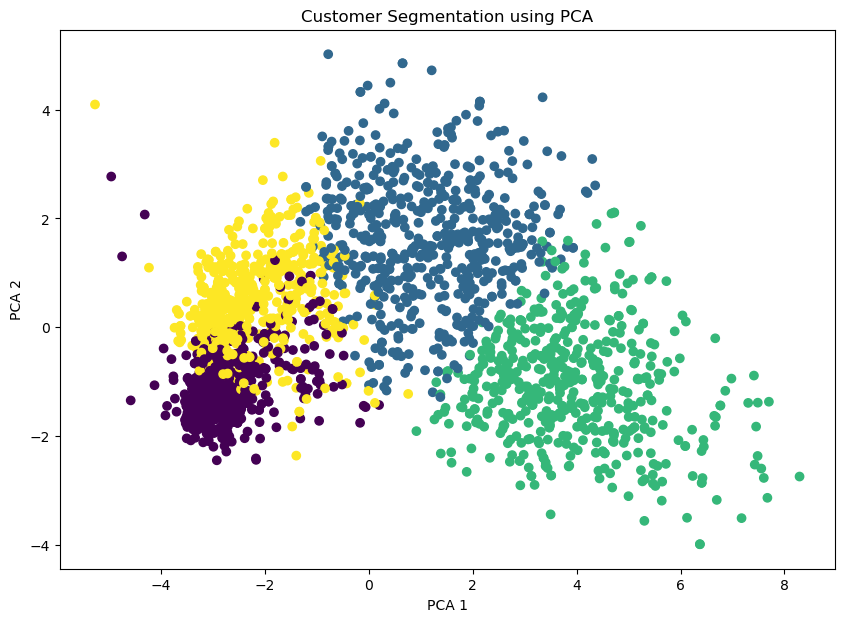

In [87]:
#Cluster Visualization
plt.figure(figsize=(10,7))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=clusters,
    cmap='viridis'
)

plt.title("Customer Segmentation using PCA")

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

In [88]:
#Business Insights
cluster_analysis = df.groupby("Cluster").mean()

cluster_analysis

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Total_Spending,Total_Purchases,DBSCAN_Cluster,HC_Cluster
Cluster,,,,,,,,,,,,,,,,,,,,,
0,1978.165217,2.041739,3.686957,29337.426087,0.857391,0.034783,48.264348,31.419130,6.193043,25.784348,...,0.001739,0.000000,0.013913,3.0,11.0,0.125217,96.775652,5.791304,0.008696,0.290435
1,1965.008681,2.651042,3.678819,59512.206597,0.194444,0.878472,48.442708,498.269097,27.435764,152.953125,...,0.031250,0.015625,0.010417,3.0,11.0,0.121528,807.046875,18.163194,-0.843750,2.102431
2,1968.649718,2.333333,3.790960,78346.849341,0.035782,0.143126,49.457627,625.039548,68.819209,475.109228,...,0.231638,0.035782,0.003766,3.0,11.0,0.297552,1419.372881,19.563089,-1.000000,2.139360
3,1963.039326,2.556180,3.754682,43126.743446,0.664794,0.970037,49.990637,73.254682,4.677903,27.814607,...,0.000000,0.003745,0.009363,3.0,11.0,0.061798,133.121723,6.829588,-0.189139,0.595506


In [90]:
#Saving files
import joblib

joblib.dump(stack, "best_classifier.pkl")
joblib.dump(lgbm, "lightgbm_backup.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(kmeans, "customer_segmentation.pkl")

print("Files saved successfully!")

Files saved successfully!


In [91]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'best_classifier.pkl', 'customer_segmentation.pkl', 'lightgbm_backup.pkl', 'marketing_campaign.csv', 'scaler.pkl', 'Untitled.ipynb']
